In [18]:
import lir_proteome_screen_pssm.environment as env
import pandas as pd
import numpy as np
from localcider.sequenceParameters import SequenceParameters
import matplotlib.pyplot as plt
plt.style.use('custom_standard')
plt.style.use('custom_small')
import seaborn as sns
import lir_proteome_screen_pssm.sequence_utils as seqtools

%load_ext autoreload
%autoreload 2
# pd.options.plotting.backend = "plotly"

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [ ]:
import re
x = 'EDWDMLDVDEDEKLTGEEEFELLLVRLV'
print(list(seqtools.get_regex_matches(seqtools.regex2overlapping(r'...[FWY].{2,3}[WFYILV]'), x)))
print(list(seqtools.get_regex_matches(
    seqtools.regex2overlapping(
        r'(...[FWY]..[WFYILV])|(...[FWY]...[WFYILV])'
    ), 
    x
)))
print(list(seqtools.get_overlapping_regex_matches(r'...[FWY].{2,3}[WFYILV]', x)))
print(list(seqtools.get_overlapping_regex_matches_v2(r'...[FWY].{2,3}[WFYILV]', x)))

[('EEEFELLL', 16, 23)]
[('EEEFELL', 16, 22)]
[('EEEFELLL', 16, 24)]
[(16, 24, 'EEEFELLL')]


In [3]:
full_data_table = pd.read_csv(env.RAWFILEPATHS.full_screening_table_2, sep=',')
# full_data_table['ID'] = 'PLR' + full_data_table['ID'] # I don't think we need this because we're not using a regex with sites preceding the match
full_data_table = full_data_table[~full_data_table['ID'].str.contains(r'HPQ', regex=True)]
assert full_data_table.duplicated(subset=["ID"], keep=False).sum() == 0, "There should be no duplicate IDs in the full data table"
regexes = [r'[FWY]..[ILV]',r'[FWY]..[WFY]',r'[FWY]..[WFYILV]', r'[FWY]...[WFYILV]']
for regex in regexes:
    full_data_table['contains_' + regex] = full_data_table['ID'].str.contains(regex, regex=True)

In [4]:
full_data_table.sort_values(by='6 Count', ascending=False)

,Unnamed: 0,ID,ER 0,ER 1,ER 3,ER 4,ER 5,ER 6,Cluster Id,Input Count,...,E-value,Score (Bits),z_score_4,z_score_5,z_score_6,avg_z_score,contains_[FWY]..[ILV],contains_[FWY]..[WFY],contains_[FWY]..[WFYILV],contains_[FWY]...[WFYILV]
0,229422,DIDNFDIDDFDDDDDWEDICII,0,4.094998,9.506665,12.105609,13.229315,14.031836,229609,976,...,1.900000e+00,23.1,3.574377,4.082822,4.670163,4.11,True,False,True,False
11,229428,DIDNFDIDDFDDDDDWEDIMHNLAASKSSTAAYQPI,0,5.401556,9.671734,11.426329,12.075933,12.376433,229616,973,...,1.370000e-18,75.5,3.284647,3.603398,3.976728,3.62,True,False,True,False
1,683178,LWQPHSSKQDDMWEHIAISML,0,4.420856,9.955033,12.104137,12.854852,13.584948,683868,244,...,4.550000e-07,42.0,3.573749,3.927170,4.482965,3.99,True,False,True,False
5,396328,IWYWSDEFGSWQEYGRQGTVTL,0,5.208992,9.572567,11.569644,12.334340,12.643501,396696,319,...,2.580000e-10,51.2,3.345774,3.710809,4.088600,3.72,False,True,True,True
28,273332,EDWDMLDVDEDEKLTGEEEFELLAGPLGLNDRRIVP,0,5.699222,9.236899,10.764586,11.127201,11.458504,273569,546,...,2.840000e-20,80.1,3.002397,3.209040,3.592215,3.27,True,False,True,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
331388,323888,KQDISERLISAALFLRFLCPANMSPSLFNLMQEYSD,0,NaN,NaN,NaN,NaN,NaN,324173,1,...,1.270000e-16,69.7,NaN,NaN,NaN,NaN,False,True,True,True
331389,323889,EVFASWRLRCAERGREDIADRLISASLFLRFLCPAI,0,NaN,NaN,NaN,NaN,NaN,324174,24,...,7.540000e-21,82.0,NaN,NaN,NaN,NaN,False,True,True,True
331390,323890,KQDISERLISASLFLRFLCPPLCLRVFSTLCRSIL,0,NaN,NaN,NaN,NaN,NaN,324175,14,...,2.800000e-07,43.1,NaN,NaN,NaN,NaN,True,True,True,True
331391,323892,KAEQDITTLEQSISRLEGQVLRYKTAAENARKLKM,0,NaN,NaN,NaN,NaN,NaN,324177,14,...,2.140000e-14,63.5,NaN,NaN,NaN,NaN,False,False,False,False


In [5]:
# %%
# ==============================================================================
# // nonbinders
# ==============================================================================
# sequences with >= 50 input counts and negative z-scores in sort 1 and 3, then no counts in sorts 4,5,6
input_count_cutoff = 50
screen_nonbinders_df = full_data_table[
    full_data_table["Input Count"] >= input_count_cutoff
].copy()
screen_nonbinders_df = screen_nonbinders_df[
    (screen_nonbinders_df['ER 1'] < 0) &
    (screen_nonbinders_df['ER 3'] < 0)
].copy()
screen_nonbinders_df = screen_nonbinders_df[
    (screen_nonbinders_df['4 Count'] == 0) &
    (screen_nonbinders_df['5 Count'] == 0) &
    (screen_nonbinders_df['6 Count'] == 0)
].copy()
full_data_table['nonbinder'] = full_data_table['ID'].isin(screen_nonbinders_df['ID'])

In [6]:
# ==============================================================================
# // binders
# ==============================================================================
screen_binders_df = full_data_table[full_data_table['avg_z_score'] >= 1.7].copy()
screen_binders_df = screen_binders_df[screen_binders_df['Input Count'] >= 10].copy()
full_data_table['binder'] = full_data_table['ID'].isin(screen_binders_df['ID'])

In [7]:
# %%
# ==============================================================================
# // final_data_table
# ==============================================================================
df = full_data_table[full_data_table['Input Count'] >= 10].copy()
assert df['nonbinder'].sum() == len(screen_nonbinders_df)
assert df['binder'].sum() == len(screen_binders_df)

In [8]:
df

,Unnamed: 0,ID,ER 0,ER 1,ER 3,ER 4,ER 5,ER 6,Cluster Id,Input Count,...,z_score_4,z_score_5,z_score_6,avg_z_score,contains_[FWY]..[ILV],contains_[FWY]..[WFY],contains_[FWY]..[WFYILV],contains_[FWY]...[WFYILV],nonbinder,binder
0,229422,DIDNFDIDDFDDDDDWEDICII,0,4.094998,9.506665,12.105609,13.229315,14.031836,229609,976,...,3.574377,4.082822,4.670163,4.11,True,False,True,False,False,True
1,683178,LWQPHSSKQDDMWEHIAISML,0,4.420856,9.955033,12.104137,12.854852,13.584948,683868,244,...,3.573749,3.927170,4.482965,3.99,True,False,True,False,False,True
2,426137,VIEEADLDGDGSWALLTSRT,0,6.061220,10.521183,11.960512,12.786388,12.782009,426523,10,...,3.512489,3.898712,4.146620,3.85,True,False,True,False,False,True
3,480519,LHNPESGEEAVALLEELQRDLGWDILA,0,5.191722,10.334677,12.020974,12.594453,12.509488,480943,13,...,3.538278,3.818930,4.032463,3.80,True,False,True,False,False,True
4,810153,QIPENSTSSQADDEWCYVLI,0,5.148098,10.131437,11.838327,12.629829,12.705135,810989,91,...,3.460374,3.833635,4.114419,3.80,True,False,True,True,False,True
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
968935,968935,YWITIDNPYVVAWHGYATGRLAPGIRGSPRLGYLVA,0,3.249749,NaN,NaN,NaN,NaN,969972,27,...,NaN,NaN,NaN,NaN,True,True,True,True,False,False
968939,968939,YWKESDKLLLIGLPAEEVPLPRLRNMIENVIQTLKF,0,2.764096,1.467049,-0.573207,NaN,NaN,969976,64,...,NaN,NaN,NaN,NaN,False,False,False,False,False,False
968940,968940,YWKNESGTWIQYGEEKDKRKNSNVDSSYLESLYQSC,0,0.565013,NaN,NaN,NaN,NaN,969977,31,...,NaN,NaN,NaN,NaN,False,True,True,True,False,False
968946,968946,YWKYGEAASTECNSVCFGDHTQPCGGDGRIILFDTL,0,NaN,NaN,NaN,NaN,NaN,969983,34,...,NaN,NaN,NaN,NaN,True,True,True,False,False,False


In [9]:
ciderdf = pd.read_csv('./localcider_results.csv')
ciderdf['seq length'] = ciderdf['ID'].str.len()
prop_cols = [i for i in ciderdf.columns if i != 'ID']

In [10]:
dfm = pd.merge(df, ciderdf, on='ID', how='inner', validate='one_to_one')

In [11]:
# Create a categorical label column based on the three boolean columns
dfm['binding_category'] = 'other'
dfm.loc[dfm['binder'], 'binding_category'] = 'binder'
dfm.loc[dfm['nonbinder'], 'binding_category'] = 'nonbinder'

# Convert to categorical for better memory usage and performance
dfm['binding_category'] = dfm['binding_category'].astype('category')

# Display the value counts
print(dfm['binding_category'].value_counts())

binding_category
other        476259
nonbinder      9093
binder          420
Name: count, dtype: int64


<Axes: xlabel='uversky_hydropathy', ylabel='Density'>

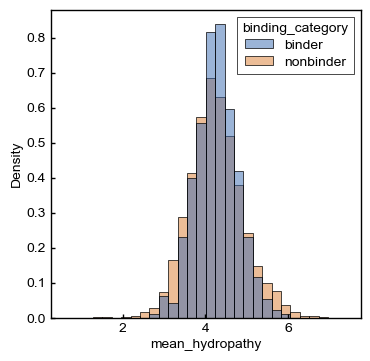

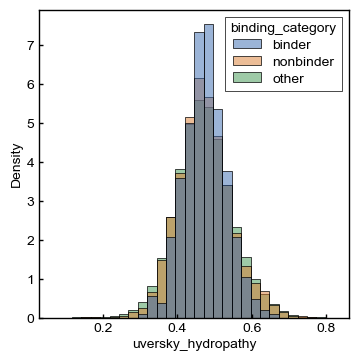

In [12]:
# sns.histplot(data=dfm, x='mean_hydropathy', hue='binding_category', element='step', stat='density', common_norm=False, hue_order=['binder','nonbinder'])
sns.histplot(data=dfm, x='mean_hydropathy', hue='binding_category', stat='density', common_norm=False, hue_order=['binder','nonbinder'], bins=30)
plt.figure()
sns.histplot(data=dfm, x='uversky_hydropathy', hue='binding_category', stat='density', common_norm=False, hue_order=['binder','nonbinder', 'other'], bins=30)

In [13]:
import math

def plot_histograms(df, prop_cols, hue_order=['binder', 'nonbinder', 'other'], hue_col='binding_category'):
    """Plot histograms of multiple properties in a grid layout."""
    n_plots = len(prop_cols)
    # Calculate grid dimensions
    n_cols = 4
    n_rows = math.ceil(n_plots / n_cols)
    fig, axes = plt.subplots(n_rows, n_cols, figsize=(16, 4 * n_rows))
    axes = axes.flatten()
    for i, prop in enumerate(prop_cols):
        sns.histplot(data=df, x=prop, hue=hue_col, 
                    stat='density', common_norm=False, 
                    # hue_order=['binder', 'nonbinder', 'other'], 
                    hue_order=hue_order,
                    bins=30, ax=axes[i])
        axes[i].set_title(prop)
    for i in range(n_plots, len(axes)):
        axes[i].set_visible(False)
    plt.tight_layout()

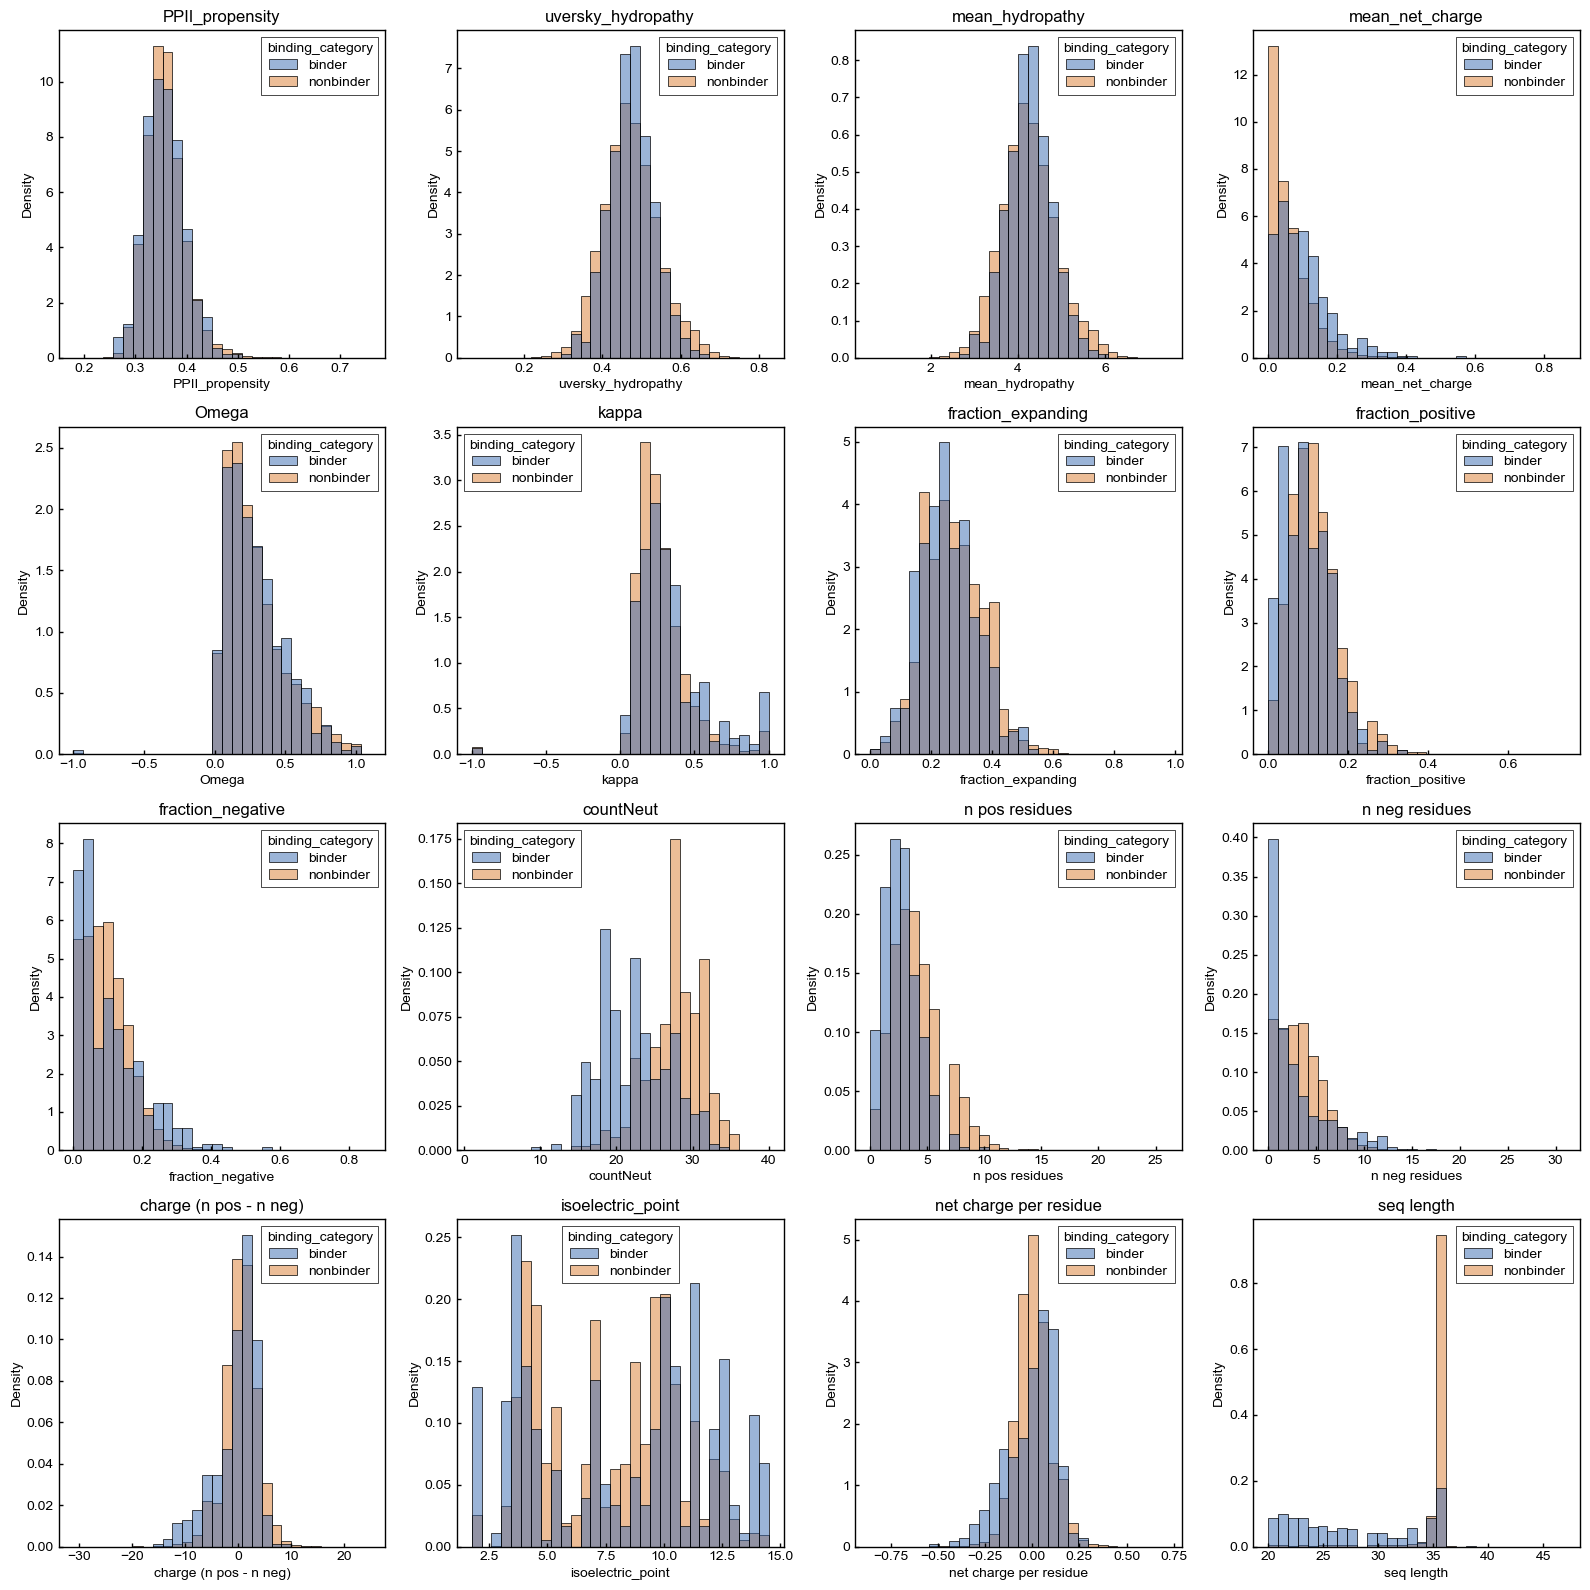

In [14]:
plot_histograms(dfm, prop_cols, hue_order=['binder', 'nonbinder'])

# short sequences

binding_category
other        190204
nonbinder      9093
binder           69
Name: count, dtype: int64


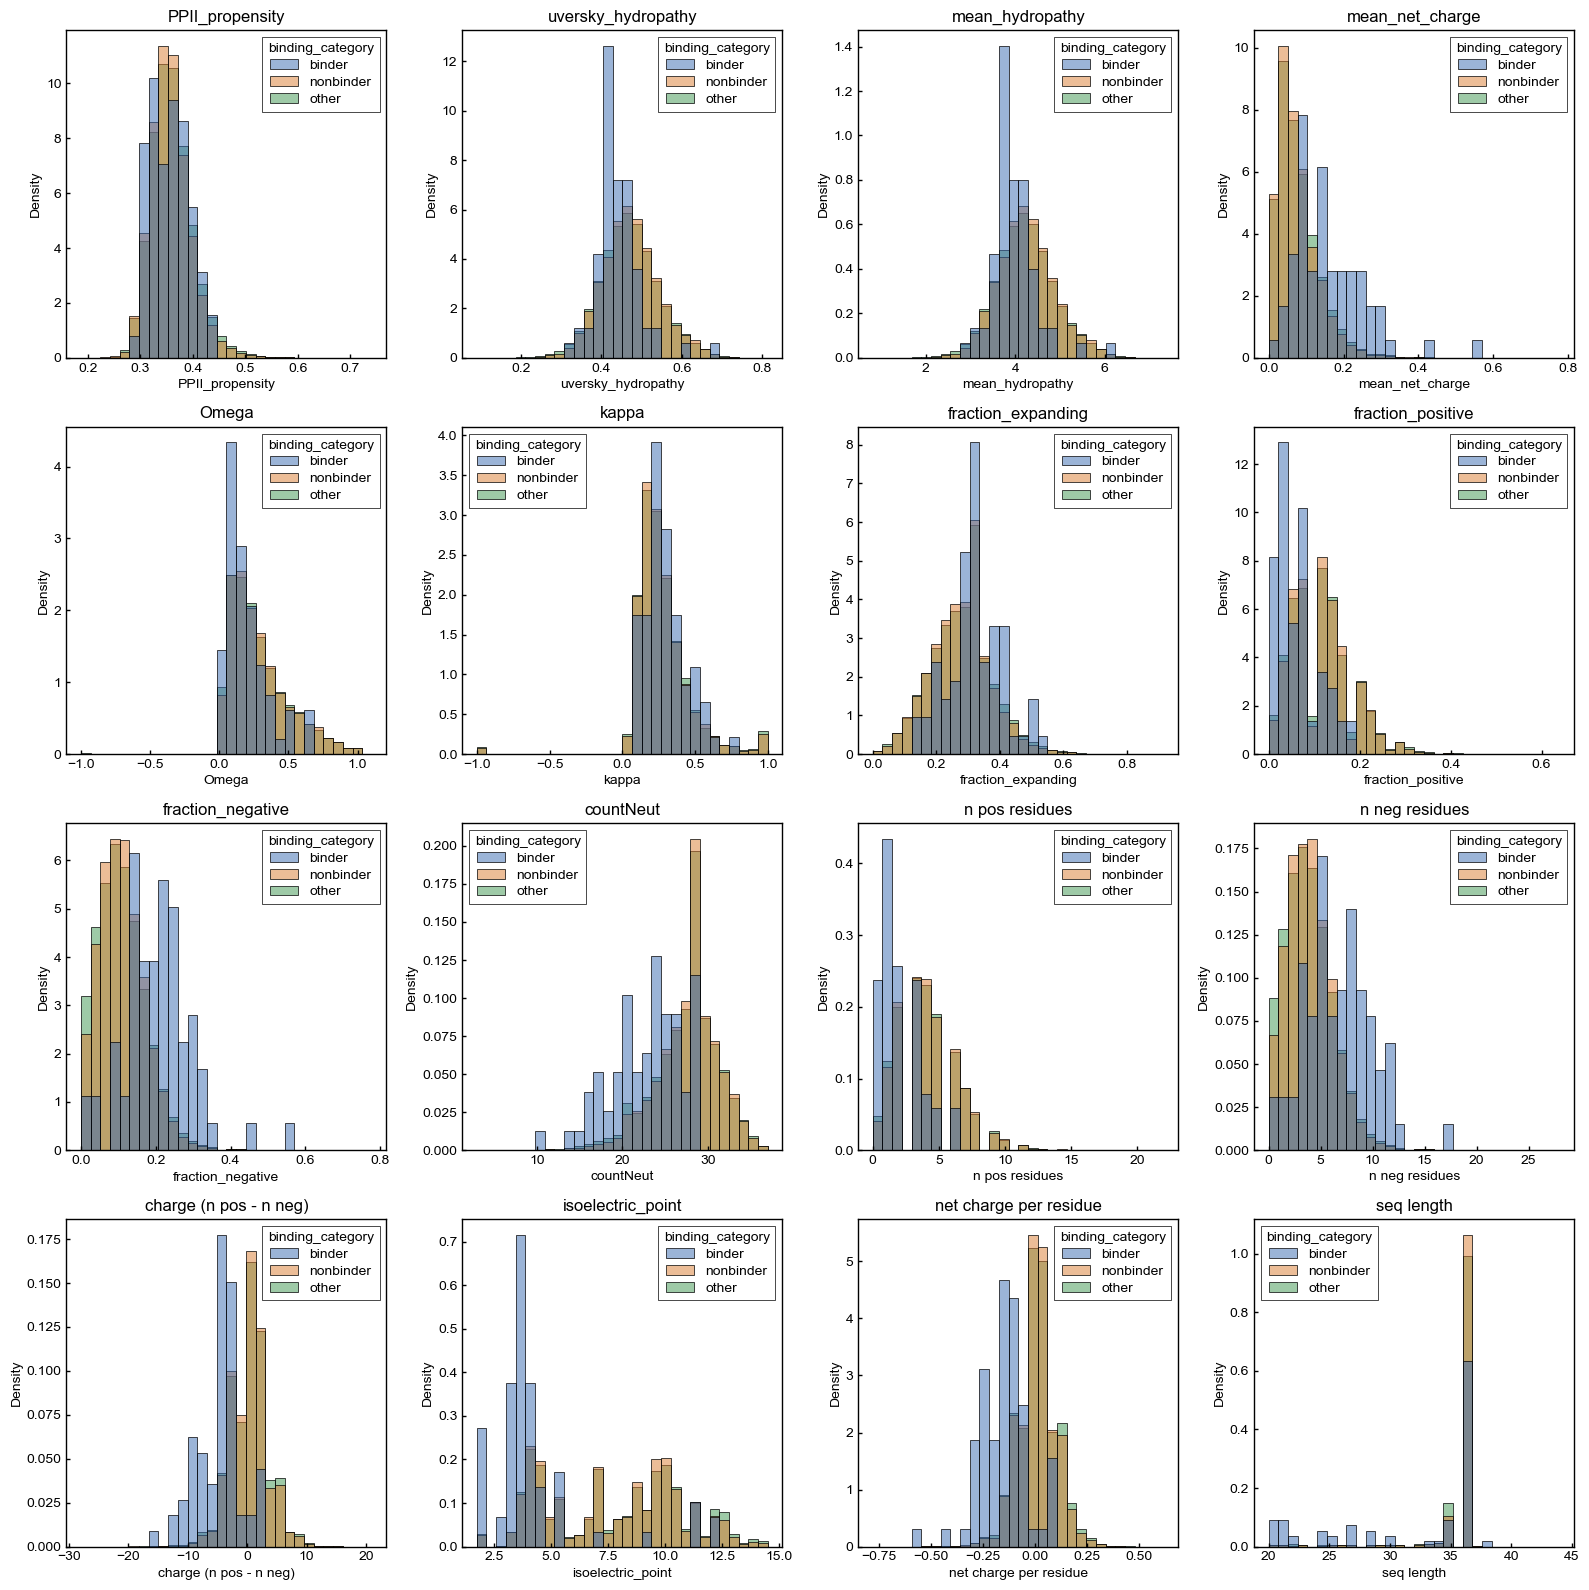

In [15]:
temp = dfm[dfm['Input Count'] >= 50].copy()
print(temp['binding_category'].value_counts())
plot_histograms(temp, prop_cols)

In [56]:
temp = dfm[dfm['Input Count'] < 50].copy()
temp[temp['binding_category']=='binder']

,Unnamed: 0,ID,ER 0,ER 1,ER 3,ER 4,ER 5,ER 6,Cluster Id,Input Count,...,fraction_positive,fraction_negative,countNeut,n pos residues,n neg residues,charge (n pos - n neg),isoelectric_point,net charge per residue,seq length,binding_category
2,426137,VIEEADLDGDGSWALLTSRT,0,6.061220,10.521183,11.960512,12.786388,12.782009,426523,10,...,0.050000,0.250000,14,1,5,-4,3.390625,-0.200000,20,binder
3,480519,LHNPESGEEAVALLEELQRDLGWDILA,0,5.191722,10.334677,12.020974,12.594453,12.509488,480943,13,...,0.037037,0.259259,19,1,7,-6,3.609375,-0.222222,27,binder
6,273333,EDWDMLDVDEDEKLTGEEEFELLLVRLV,0,4.290391,10.297456,11.862116,12.408549,12.249456,273570,12,...,0.071429,0.428571,14,2,12,-10,3.281250,-0.357143,28,binder
7,139933,ASTISSNASKGREAMEWVIIN,0,5.985777,9.823032,11.826119,12.320888,12.062774,140043,11,...,0.095238,0.095238,17,2,2,0,7.000000,0.000000,21,binder
12,154844,DVWEILRRHRHLSTSASPSSTASLTCAAC,0,5.552485,9.660099,11.500042,12.169792,11.910367,154968,24,...,0.103448,0.068966,24,3,2,1,8.531250,0.034483,29,binder
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
414,104183,TPGLKIPSTKNSIALVSTNYPLSKTNSSSMIGS,0,5.605746,7.922032,7.837726,6.904724,7.428568,104262,11,...,0.090909,0.000000,30,3,0,3,10.500000,0.090909,33,binder
415,136623,ASQGSDDDWDDEWDDSSTVADEPGALGSGAYPDLDG,0,6.093138,7.077381,7.625063,7.758434,6.743610,136733,28,...,0.000000,0.333333,24,0,12,-12,1.750000,-0.333333,36,binder
416,608085,LEATGPGGSQAINNLRRSNSTTQVSQPRSGSPRPTE,0,6.929649,7.823032,8.205766,7.752720,6.165534,608664,11,...,0.111111,0.055556,30,4,2,2,12.468750,0.055556,36,binder
418,723996,MSQAVQQRYSTIKQNMGTQFI,0,3.409332,7.021036,7.790198,7.932998,6.418514,724743,48,...,0.095238,0.000000,19,2,0,2,11.375000,0.095238,21,binder


binding_category
other        196242
nonbinder      4210
binder          214
Name: count, dtype: int64


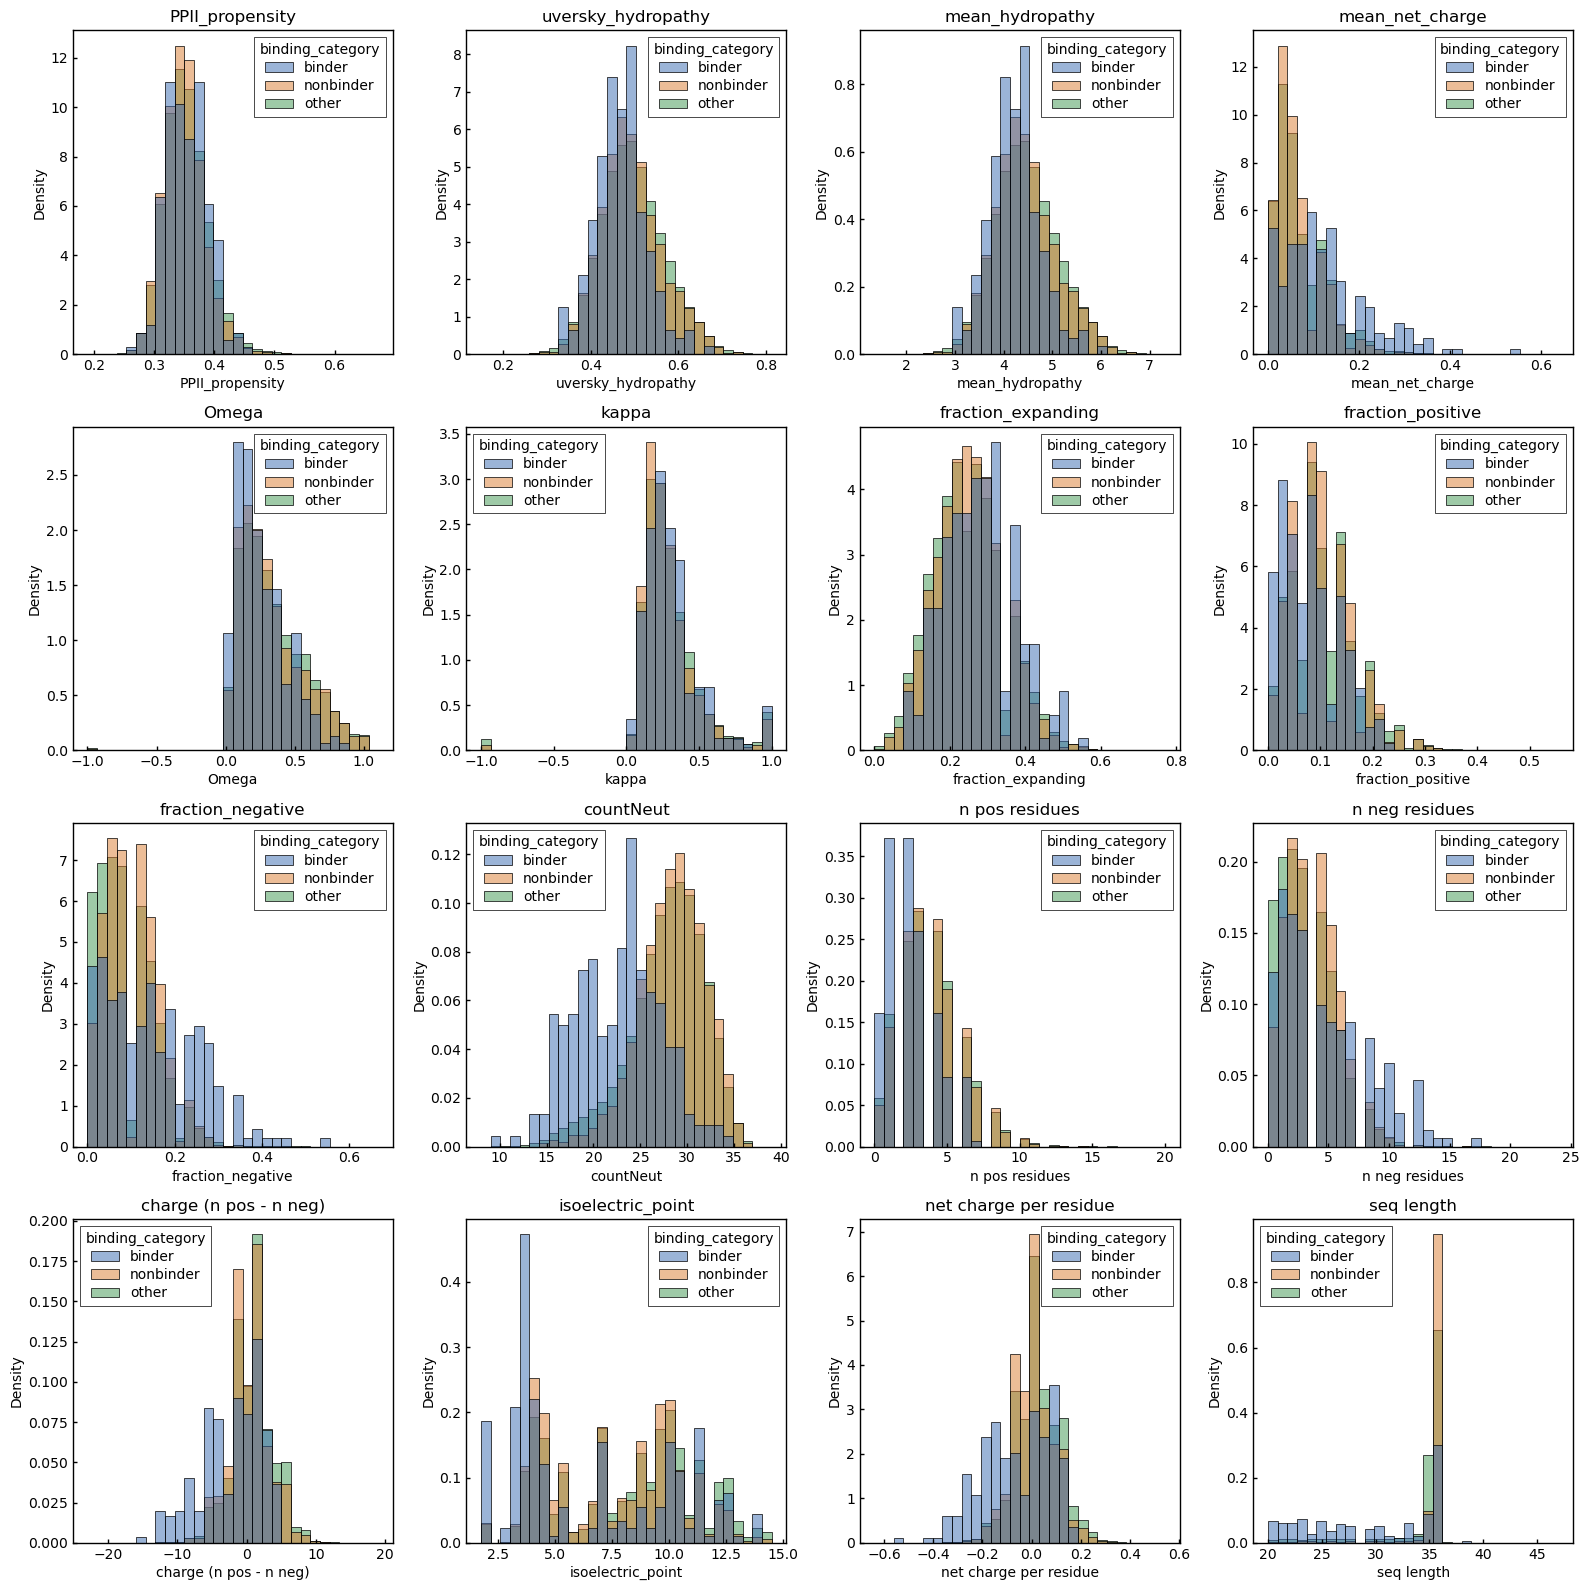

In [52]:
temp = dfm[dfm['contains_[FWY]..[ILV]']].copy()
print(temp['binding_category'].value_counts())
plot_histograms(temp, prop_cols, hue_order=None)

binding_category
other        241044
nonbinder      3981
binder          178
Name: count, dtype: int64


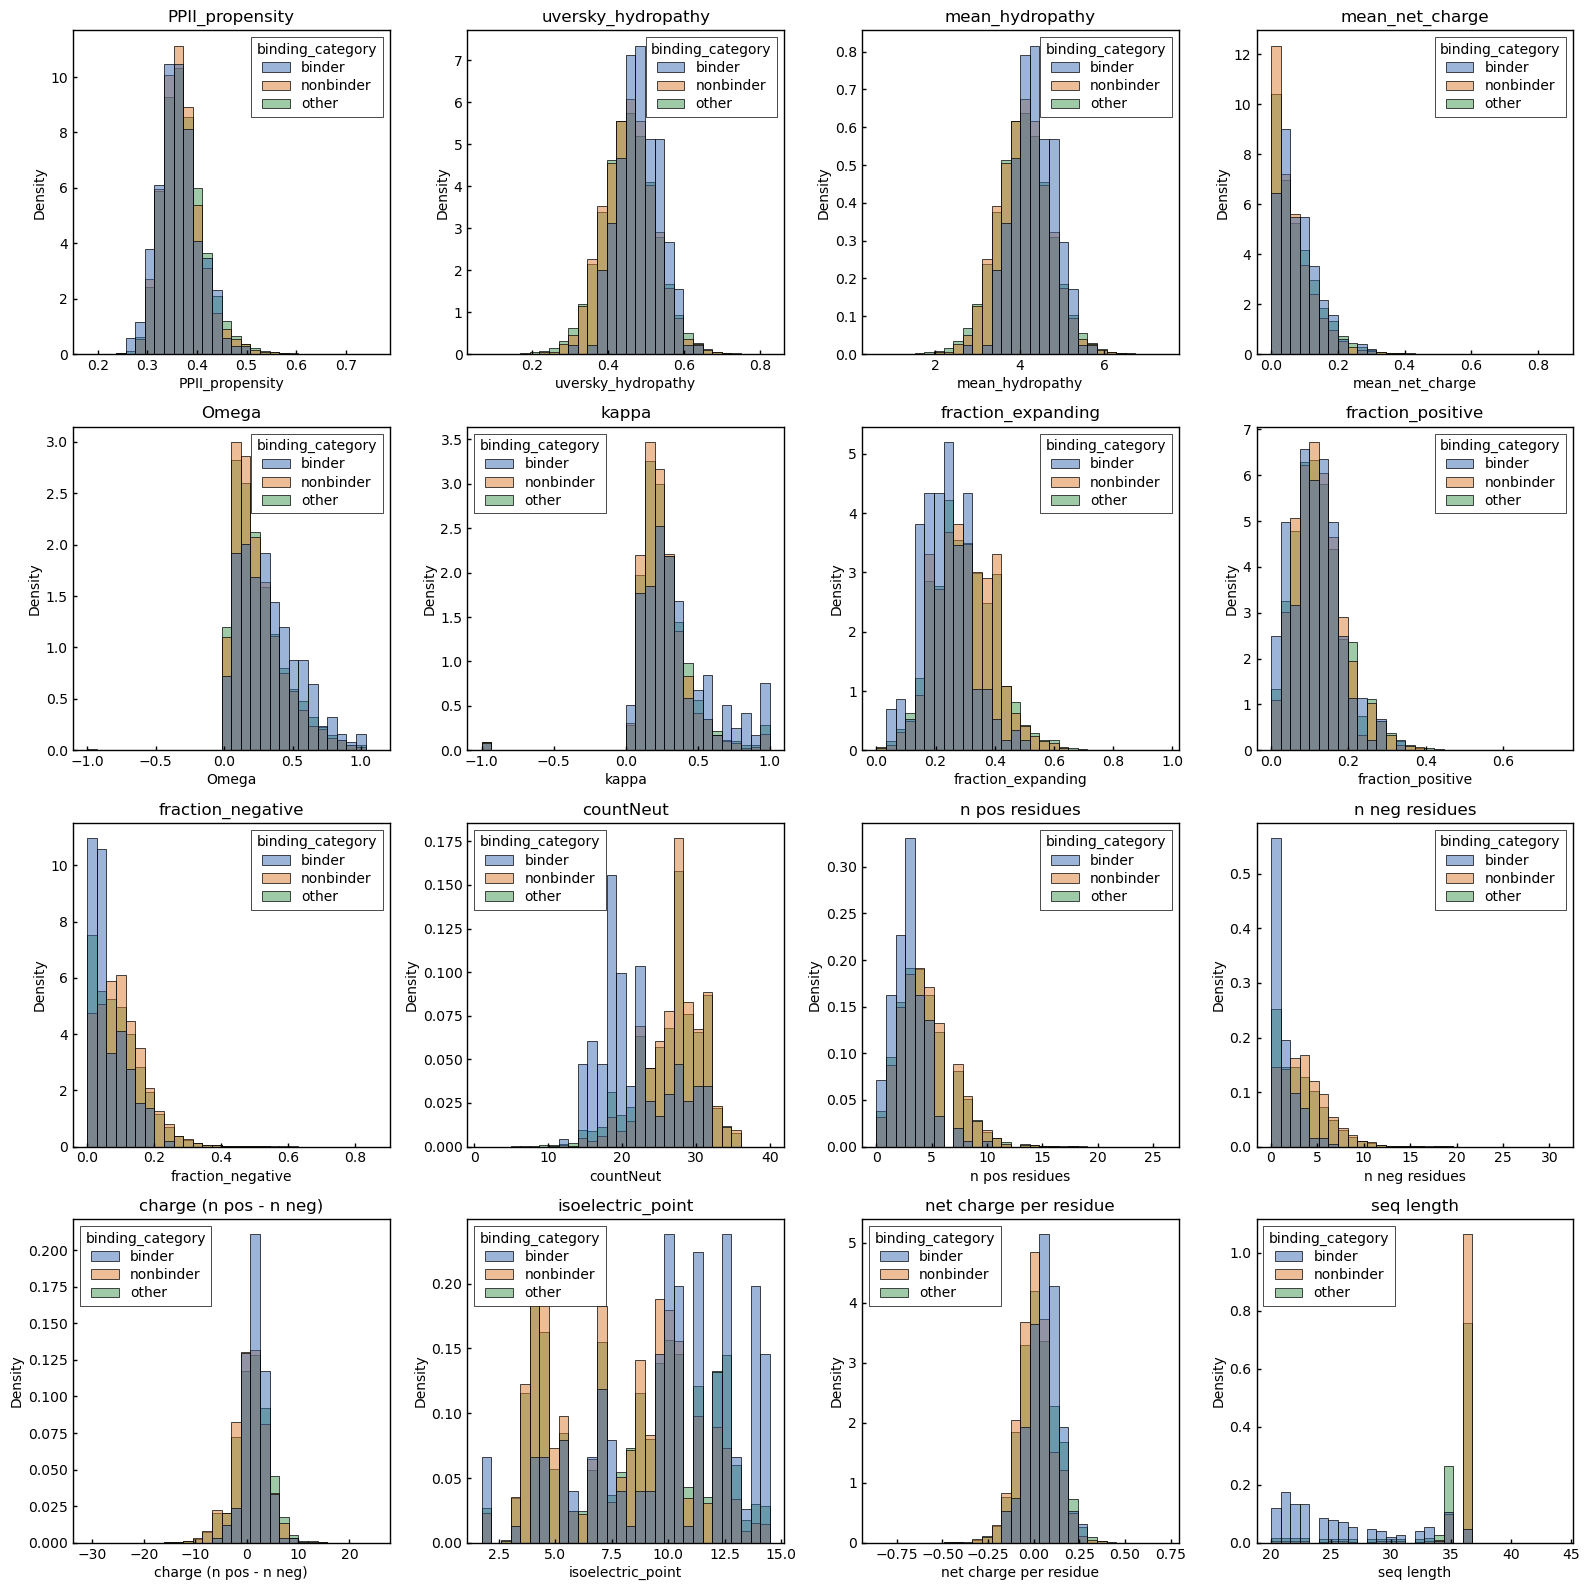

In [ ]:
temp = dfm[~dfm['contains_[FWY]..[ILV]']].copy()
temp = temp[~temp['contains_[FWY]..[WFY]']].copy()
print(temp['binding_category'].value_counts())
plot_histograms(temp, prop_cols, hue_order=None)

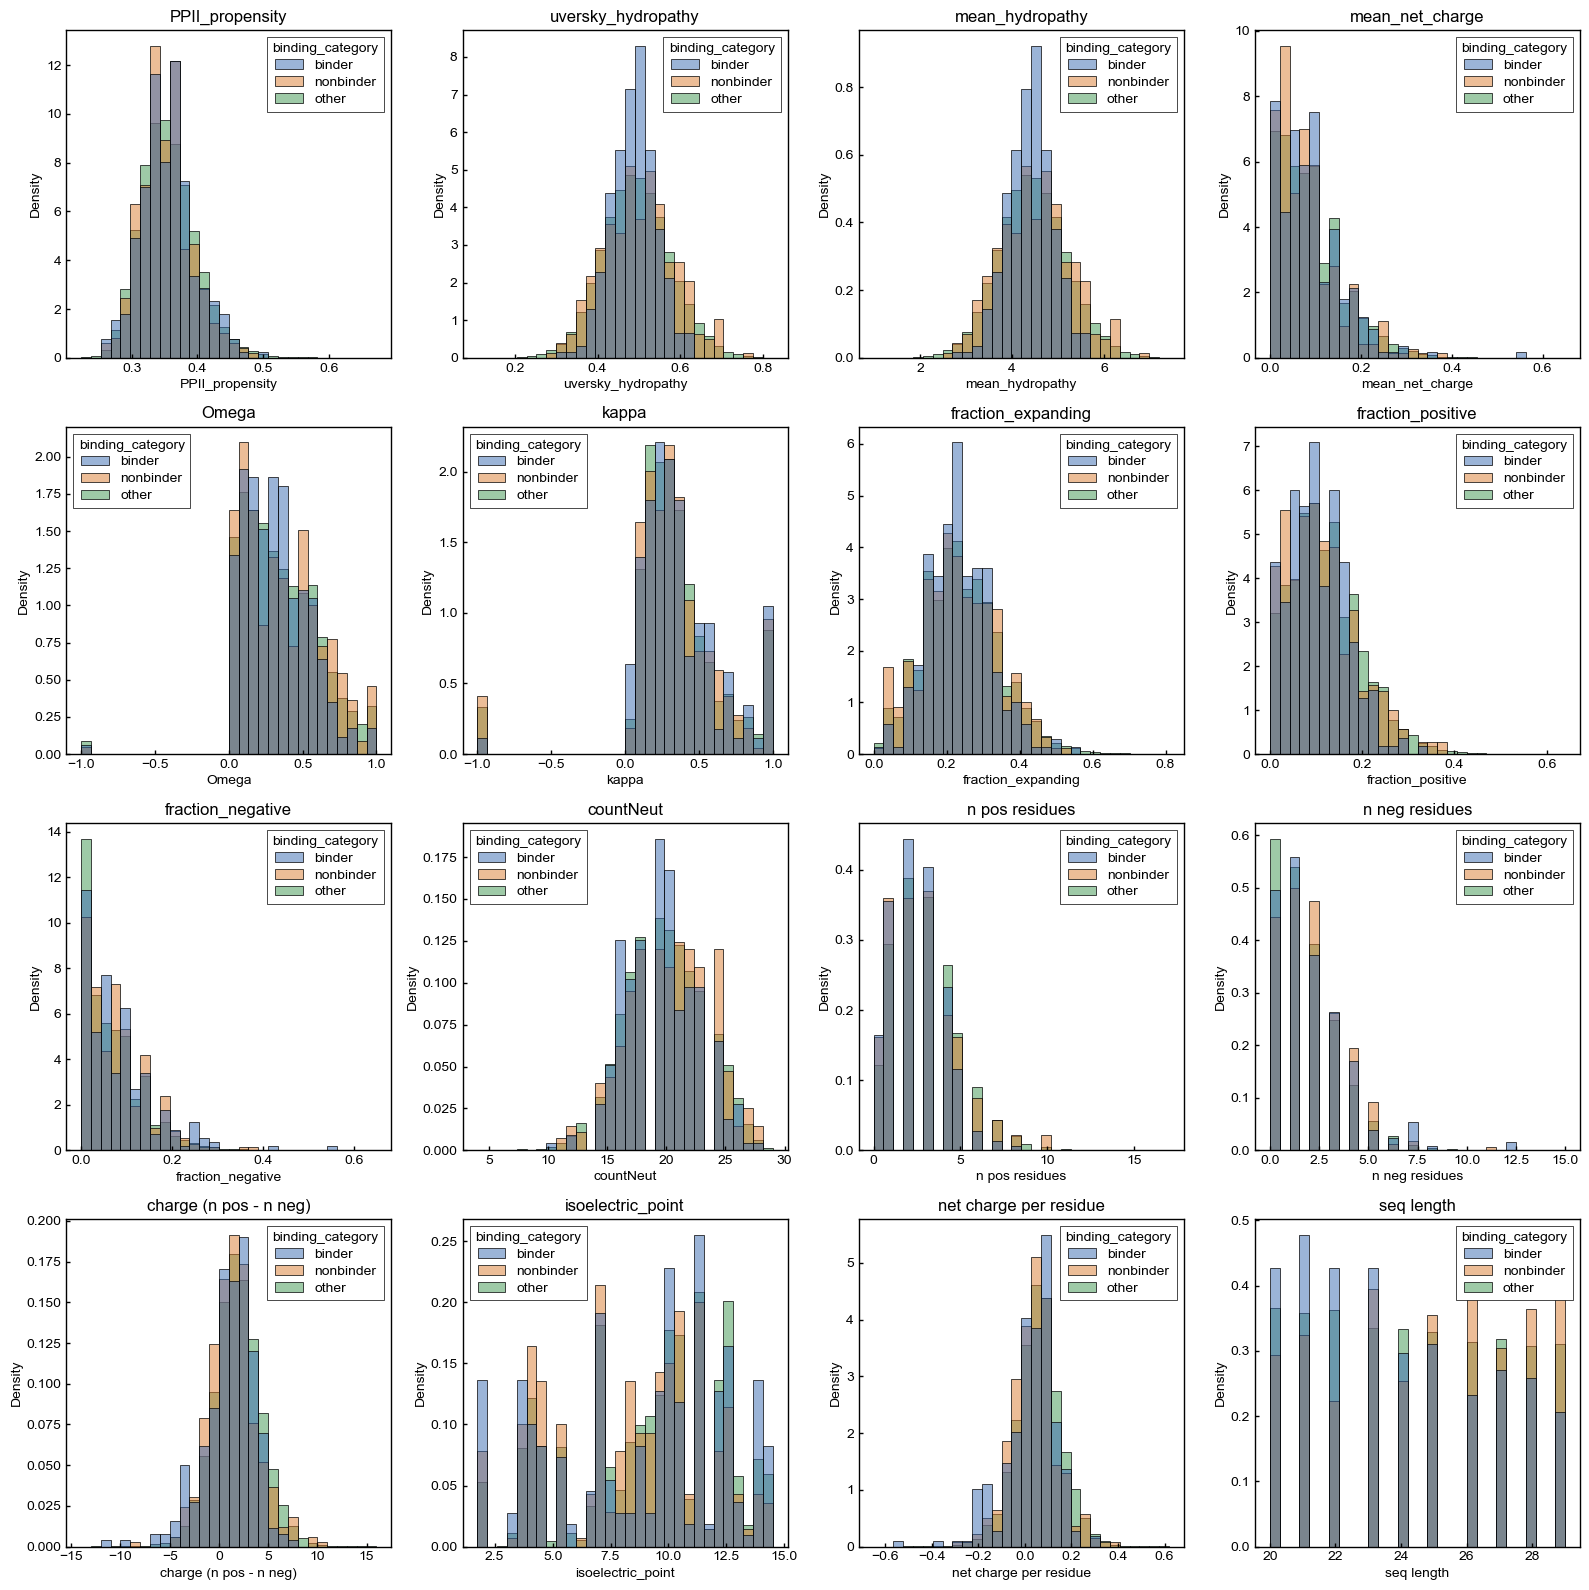

In [16]:
temp = dfm[dfm['seq length'] < 30].copy()
plot_histograms(temp, prop_cols, hue_order=None)

<Axes: xlabel='seq length', ylabel='Count'>

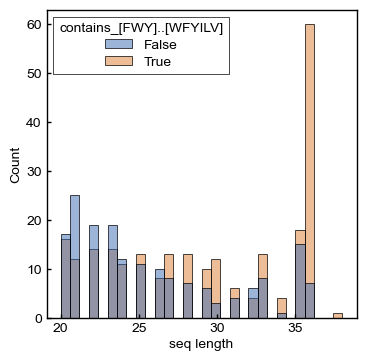

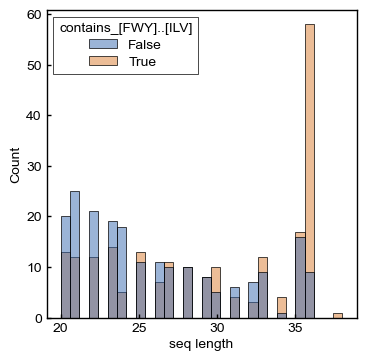

In [17]:
temp = dfm[dfm['binding_category']=='binder'].copy()
# sns.histplot(data=temp, x='seq length', stat='density', bins=30, hue='contains_[FWY]..[WFYILV]', common_norm=False)
sns.histplot(data=temp, x='seq length', bins=30, hue='contains_[FWY]..[WFYILV]', common_norm=False)
plt.figure()
sns.histplot(data=temp, x='seq length', bins=30, hue='contains_[FWY]..[ILV]', common_norm=False)

In [14]:
import lir_proteome_screen_pssm.pssms as pssms

In [15]:
short_binders = dfm[(dfm['binding_category']=='binder') & (dfm['seq length'] < 30)].copy()
# short_binders['contains_[FWY]..[ILV]'].value_counts()
short_binders['contains_[FWY]..[WFYILV]'].value_counts()

contains_[FWY]..[WFYILV]
False    134
True     124
Name: count, dtype: int64

<Axes: >

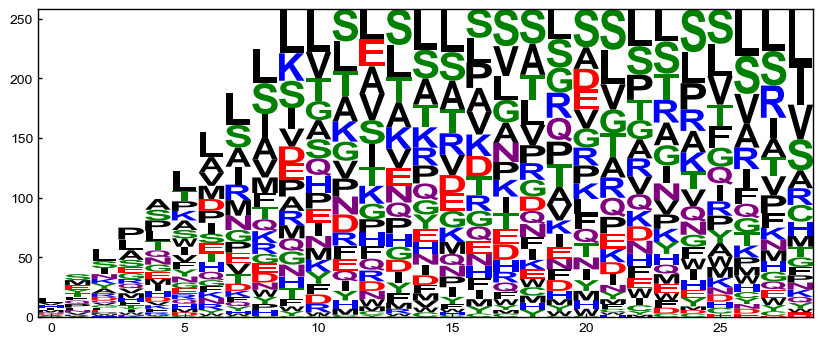

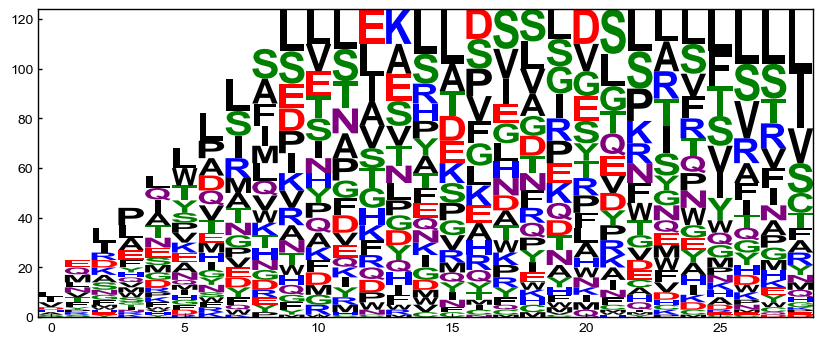

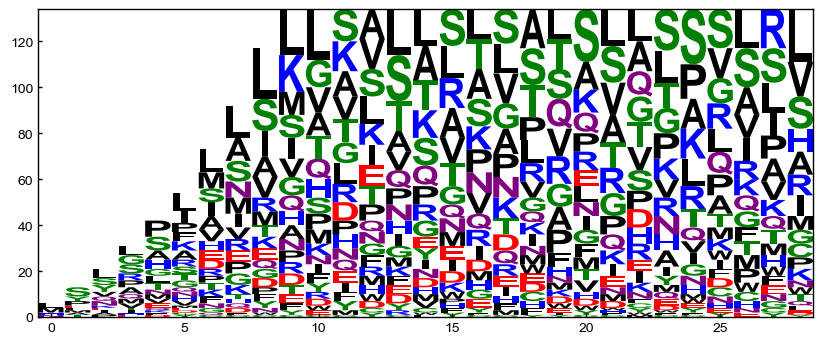

In [51]:
def right_align_sequences(sequences):
    """
    Right align a list of sequences by padding them with '-' characters.
    
    Parameters:
    sequences (list): List of sequence strings
    
    Returns:
    list: List of right-aligned sequences with '-' padding
    """
    max_length = max(len(seq) for seq in sequences)
    aligned_sequences = []
    for seq in sequences:
        padding = '-' * (max_length - len(seq))
        aligned_sequences.append(padding + seq)
    return aligned_sequences


def plot_right_aln_logo(df, ax=None):
    if ax is None:
        fig, ax = plt.subplots(figsize=(10, 4))
    aligned_seqs = right_align_sequences(df['ID'].tolist())
    pssms.plot_logo(pssms.alignment_2_counts(aligned_seqs), ax=ax)
    return ax


plot_right_aln_logo(short_binders)
plot_right_aln_logo(short_binders[short_binders['contains_[FWY]..[WFYILV]']])
plot_right_aln_logo(short_binders[~short_binders['contains_[FWY]..[WFYILV]']])

contains_[FWY]..[WFYILV]
False    92
True     67
Name: count, dtype: int64


<Axes: >

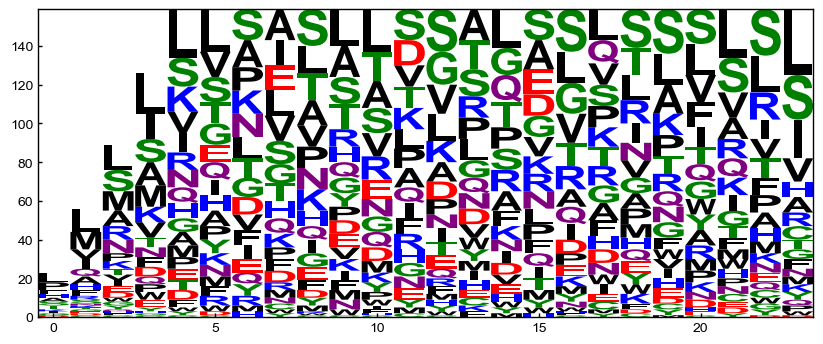

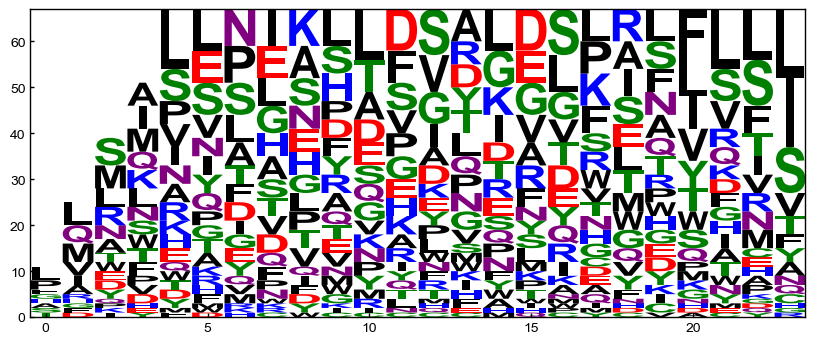

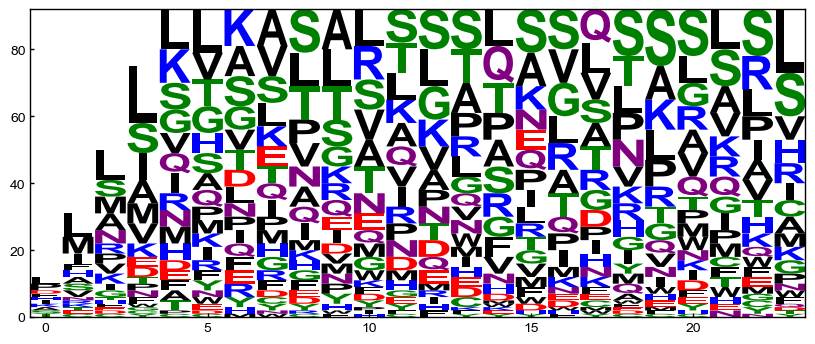

In [35]:
short_binders = dfm[(dfm['binding_category']=='binder') & (dfm['seq length'] < 25)].copy()
# short_binders['contains_[FWY]..[ILV]'].value_counts()
print(short_binders['contains_[FWY]..[WFYILV]'].value_counts())
plot_right_aln_logo(short_binders)
plot_right_aln_logo(short_binders[short_binders['contains_[FWY]..[WFYILV]']])
plot_right_aln_logo(short_binders[~short_binders['contains_[FWY]..[WFYILV]']])

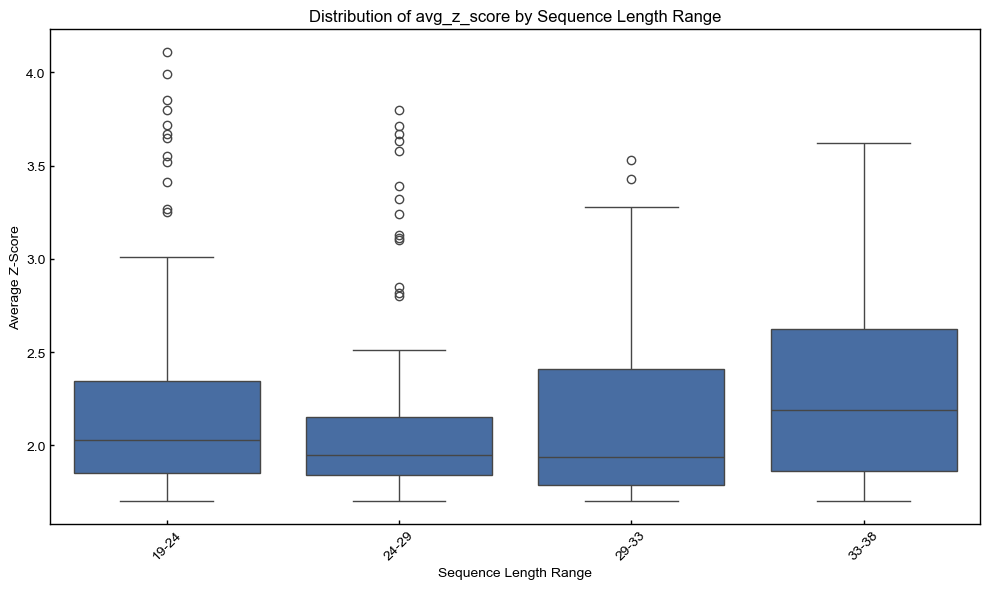

In [23]:
temp = dfm[dfm['binding_category']=='binder'].copy()
# sns.scatterplot(data=temp, x='seq length', y='avg_z_score')
# Create 4 sequence length ranges
# Create 4 sequence length ranges with actual min/max values as labels
bins = pd.cut(temp['seq length'], bins=4, retbins=True)
temp['seq_length_range'] = bins[0]
bin_edges = bins[1]

# Create custom labels with actual min/max values
labels = [f"{int(bin_edges[i])}-{int(bin_edges[i+1])}" for i in range(len(bin_edges)-1)]
temp['seq_length_range'] = pd.cut(temp['seq length'], bins=4, labels=labels)

# Create boxenplot
plt.figure(figsize=(10, 6))
sns.boxplot(data=temp, x='seq_length_range', y='avg_z_score')
plt.title('Distribution of avg_z_score by Sequence Length Range')
plt.xlabel('Sequence Length Range')
plt.ylabel('Average Z-Score')
plt.xticks(rotation=45)
plt.tight_layout()

# regex counting

In [23]:
def func1(df_in: pd.DataFrame, regex: str) -> pd.DataFrame:
    df = df_in.copy()
    df['matches'] = df.apply(get_regex_matches, axis=1, regex = regex)
    df["n_matches"] = df["matches"].apply(lambda x: len(x))
    return df[df["n_matches"] == 0].copy(), len(df[df["n_matches"] > 0])


def get_regex_matches(s: pd.Series, regex: str):
    matches = list(seqtools.get_regex_matches(regex, s["ID"]))
    # if len(matches) == 0:
    #     return
    return matches

def regex_filter_count(df: pd.DataFrame, regex_list: list[str]) -> None:
    temp = df.copy()
    total = len(df)
    for r in regex_list:
        temp, n =  func1(temp, r)
        print(f"{r}: {n} ({n/total:.2%})")


def add_matches_columns(df_in: pd.DataFrame, regex: str):
    df = df_in.copy()
    df[f'{regex}matches'] = df.apply(get_regex_matches, axis=1, regex=regex)
    df[f"{regex}n_matches"] = df[f"{regex}matches"].apply(lambda x: len(x))
    return df


def seqs_with_match(df_in: pd.DataFrame, regex_list: list[str]) -> None:
    df = df_in.copy()
    n = len(df)
    for r in regex_list:
        df = add_matches_columns(df, r)
        n_s_match = len(df[df[f'{r}n_matches']>0])
        print(f"{r}: {n_s_match} ({n_s_match/n:.2%})")


def regex_match_per_library_member(df_in: pd.DataFrame, regex_list: str) -> None:
    df = df_in.copy()
    n = len(df)
    for r in regex_list:
        df = add_matches_columns(df, r)
        print(f"{r}: {df[f'{r}n_matches'].sum()} - {df[f'{r}n_matches'].sum()/n:.3} ave matches per sequence")


def multi_regex_match_per_library_member(df_in: pd.DataFrame, regex_list: list[str]) -> None:
    df = df_in.copy()
    n = len(df)
    for r in regex_list:
        df = add_matches_columns(df, r)
        print(f"number of seqs with >1 match to {r}: {len(df[df[f'{r}n_matches']>1])} ({len(df[df[f'{r}n_matches']>1])/n:.2%})")

In [24]:
rs = [
    "...[FWY]..[LVI]",
    "...[FWY]...[LVI]",
    "...[FWY]...[LVIFWY]",
    "...[FWY]..[FWY]",
    "...[LVI]..[LVI]",
    "...[LVI]..[FWY]",
    "...[FWY]..[LVIFWY]",
]
# df = pd.read_csv(env.RAWFILEPATHS.full_screening_table_2, sep='\t')
df = pd.read_csv(env.RAWFILEPATHS.full_screening_table_2)
df = df[df['Input Count'] >=10]
bdf = df[df['avg_z_score'] >= 1.7].copy()

print(f"Binder set (avg_z_score >= 1.7) (n={len(bdf)})")
print("-------------------------------")
print('')
print("non-filtering - n sequences with a match")
seqs_with_match(bdf, rs)
print('')
print("filtering - n sequences with a match. Sequences with a match are removed from the pool for the next regex")
regex_filter_count(bdf, rs)
print('')
print("non-filtering - total number of matches (>1 match counted) - total # matches / n sequences")
regex_match_per_library_member(bdf, rs)
print('')
print("non-filtering - n sequences with >1 match")
multi_regex_match_per_library_member(bdf, rs)

# df = pd.read_csv(env.RAWFILEPATHS.full_screening_table_2)
# df = df[df['Input Count'] >=100]
print('')
print('')
print(f"input library (Input Count >= 100) (n={len(df)})")
print("-------------------------------")
print('')
print("non-filtering - n sequences with a match")
seqs_with_match(df, rs)
print('')
print("filtering - n sequences with a match. Sequences with a match are removed from the pool for the next regex")
regex_filter_count(df, rs)
print('')
print("non-filtering - total number of matches (>1 match counted) - total # matches / n sequences")
regex_match_per_library_member(df, rs)
print('')
print("non-filtering - n sequences with >1 match")
multi_regex_match_per_library_member(df, rs)

Binder set (avg_z_score >= 1.7) (n=427)
-------------------------------

non-filtering - n sequences with a match
...[FWY]..[LVI]: 204 (47.78%)
...[FWY]...[LVI]: 109 (25.53%)
...[FWY]...[LVIFWY]: 135 (31.62%)
...[FWY]..[FWY]: 60 (14.05%)
...[LVI]..[LVI]: 243 (56.91%)
...[LVI]..[FWY]: 106 (24.82%)
...[FWY]..[LVIFWY]: 232 (54.33%)

filtering - n sequences with a match. Sequences with a match are removed from the pool for the next regex
...[FWY]..[LVI]: 204 (47.78%)
...[FWY]...[LVI]: 37 (8.67%)
...[FWY]...[LVIFWY]: 11 (2.58%)
...[FWY]..[FWY]: 11 (2.58%)
...[LVI]..[LVI]: 87 (20.37%)
...[LVI]..[FWY]: 15 (3.51%)
...[FWY]..[LVIFWY]: 0 (0.00%)

non-filtering - total number of matches (>1 match counted) - total # matches / n sequences
...[FWY]..[LVI]: 235 - 0.55 ave matches per sequence
...[FWY]...[LVI]: 119 - 0.279 ave matches per sequence
...[FWY]...[LVIFWY]: 153 - 0.358 ave matches per sequence
...[FWY]..[FWY]: 67 - 0.157 ave matches per sequence
...[LVI]..[LVI]: 308 - 0.721 ave matches per 

# junk

,_UNIPROT ID,_UNIPROT ACC,6mer,_Position,_Verified,_cLIR,_xLIR,_Anchor,_PSSM score (e-value),_Species,_header,_full_length_seq,_ids_equal,_start_position,_n_matches,7mer
0,NaN,O75143,DDFVMI,442‚Äì447,Yes,Yes,Yes,Yes,20 (8.4e-03),Human,sp|O75143|ATG13_HUMAN Autophagy-related protei...,METDLNSQDRKDLDKFIKFFALKTVQVIVQARLGEKICTRSSSSPT...,True,441,1,HDDFVMI
1,Atg1_YEAST,P53104,REYVVV,427‚Äì432,Yes,No,Yes,Yes,14 (5.7e-02),Yeast,sp|P53104|ATG1_YEAST Serine/threonine-protein ...,MGDIKNKDHTTSVNHNLMASAGNYTAEKEIGKGSFATVYRGHLTSD...,True,426,1,EREYVVV
2,Atg32_YEAST,P40458,GSWQAI,84‚Äì89,Yes,No,Yes,Yes,17 (2.2e-02),Yeast,sp|P40458|ATG32_YEAST Autophagy-related protei...,MVLEYQQREGKGSSSKSMPPDSSSTTIHTCSEAQTGEDKGLLDPHL...,True,83,1,SGSWQAI
3,ATG4B_HUMAN** [MM],Q9Y4P1,LTYDTL,6‚Äì11,Yes,No,Yes,No,12 (1.1e-01),Human,sp|Q9Y4P1|ATG4B_HUMAN Cysteine protease ATG4B ...,MDAATLTYDTLRFAEFEDFPETSEPVWILGRKYSIFTEKDEILSDV...,True,5,1,TLTYDTL
4,Atg19_YEAST,P35193,LTWEEL,410‚Äì415,Yes,No,Yes,No,18 (1.6e-02),Yeast,sp|P35193|ATG19_YEAST Autophagy-related protei...,MNNSKTNQQMNTSMGYPLTVYDECNKFQLIVPTLDANIMLWCIGQL...,True,409,1,ALTWEEL
5,Atg3_YEAST,P40344,GDWEDL,268‚Äì273,Yes,No,Yes,No,22 (4.4e-03),Yeast,sp|P40344|ATG3_YEAST Autophagy-related protein...,MIRSTLSSWREYLTPITHKSTFLTTGQITPEEFVQAGDYLCHMFPT...,True,267,1,VGDWEDL
6,BNI3L_HUMAN,O60238,SSWVEL,34‚Äì39,Yes,No,Yes,Yes,20 (8.4e-03),Human,sp|O60238|BNI3L_HUMAN BCL2/adenovirus E1B 19 k...,MSSHLVEPPPPLHNNNNNCEENEQSLPPPAGLNSSWVELPMNSSNG...,True,33,1,NSSWVEL
7,NaN,P27797,DDWDFL,198‚Äì203,Yes,Yes,Yes,Yes,26 (1.2e-03),Human,sp|P27797|CALR_HUMAN Calreticulin OS=Homo sapi...,MLLSVPLLLGLLGLAVAEPAVYFKEQFLDGDGWTSRWIESKHKSDF...,True,197,1,EDDWDFL
8,NaN,P22681,FGWLSL,800‚Äì805,Yes,No,Yes,Yes,18 (1.6e-02),Human,sp|P22681|CBL_HUMAN E3 ubiquitin-protein ligas...,MAGNVKKSSGAGGGSGSGGSGSGGLIGLMKDAFQPHHHHHHHLSPH...,True,799,1,SFGWLSL
9,FUND1_HUMAN,Q8IVP5,DSYEVL,16‚Äì21,Yes,Yes,Yes,No,16 (3.0e-02),Human,sp|Q8IVP5|FUND1_HUMAN FUN14 domain-containing ...,MATRNPPPQDYESDDDSYEVLDLTEYARRHQWWNRVFGHSSGPMVE...,True,15,1,DDSYEVL


The overlapping regex matches do not work with variable length

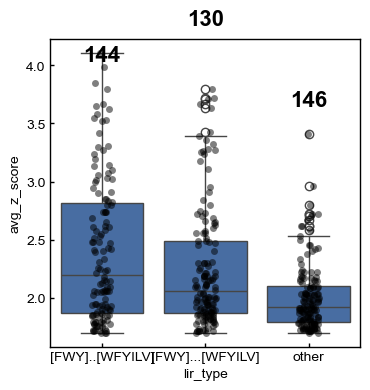

In [12]:
temp = dfm[(dfm['binding_category']=='binder')].copy()
# Create lir_type column based on the boolean values
temp['lir_type'] = temp.apply(lambda row: 
    '[FWY]...[WFYILV]' if row['contains_[FWY]...[WFYILV]'] 
    else '[FWY]..[WFYILV]' if row['contains_[FWY]..[WFYILV]'] 
    else 'other', axis=1)

fig, ax = plt.subplots()
sns.stripplot(
    data=temp,
    x="lir_type",
    y="avg_z_score",
    ax=ax,
    jitter=True,
    alpha=0.5,
    color="black",
)
sns.boxplot(
    data=temp,
    x="lir_type",
    y="avg_z_score",
    ax=ax,
)

# Add number of datapoints above each box
group_counts = temp.groupby("lir_type")["avg_z_score"].count()
for i, (lir_type, count) in enumerate(group_counts.items()):
    y_max = temp[temp["lir_type"] == lir_type]["avg_z_score"].max()
    ax.text(i, y_max + 0.2, str(count), ha="center", va="bottom", fontsize=16, fontweight="bold")


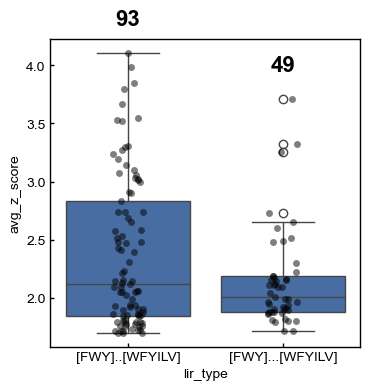

In [13]:
temp = dfm[(dfm['binding_category']=='binder')].copy()
regexi = seqtools.regex2overlapping(r'...[FWY].{2,3}[WFYILV]')
def get_regex_matches(s: pd.Series, regex: str):
    matches = list(seqtools.get_regex_matches(regex, s["ID"]))
    return matches
temp[f"{regexi}-regex_matches"] = temp.apply(get_regex_matches, axis=1, regex=regexi)
temp[f"{regexi}_num_regex_matches"] = temp[f"{regexi}-regex_matches"].apply(lambda x: len(x))
temp = temp[temp[f"{regexi}_num_regex_matches"] == 1]
temp['lir_type'] = temp.apply(lambda row: 
    '[FWY]...[WFYILV]' if row['contains_[FWY]...[WFYILV]'] 
    else '[FWY]..[WFYILV]' if row['contains_[FWY]..[WFYILV]'] 
    else 'other', axis=1)
fig, ax = plt.subplots()
sns.stripplot(
    data=temp,
    x="lir_type",
    y="avg_z_score",
    ax=ax,
    jitter=True,
    alpha=0.5,
    color="black",
)
sns.boxplot(
    data=temp,
    x="lir_type",
    y="avg_z_score",
    ax=ax,
)

# Add number of datapoints above each box
group_counts = temp.groupby("lir_type")["avg_z_score"].count()
for i, (lir_type, count) in enumerate(group_counts.items()):
    y_max = temp[temp["lir_type"] == lir_type]["avg_z_score"].max()
    # Get the x-axis position based on the order of categories in the plot
    x_pos = list(temp["lir_type"].cat.categories).index(lir_type) if hasattr(temp["lir_type"], 'cat') else list(temp["lir_type"].unique()).index(lir_type)
    ax.text(x_pos, y_max + 0.2, str(count), ha="center", va="bottom", fontsize=16, fontweight="bold")

In [94]:
import re
p = re.compile(seqtools.regex2overlapping(r'...[FWY].{2,3}[WFYILV]'))
p.findall('EDWDMLDVDEDEKLTGEEEFELLLVRLV')

['EEEFELLL']

In [76]:
temp['7mer'] = temp['(?=(...[FWY].{2,3}[WFYILV]))-regex_matches'].apply(lambda x: x[0][0])

LogomakerError: all elements of sequences must have the same length.

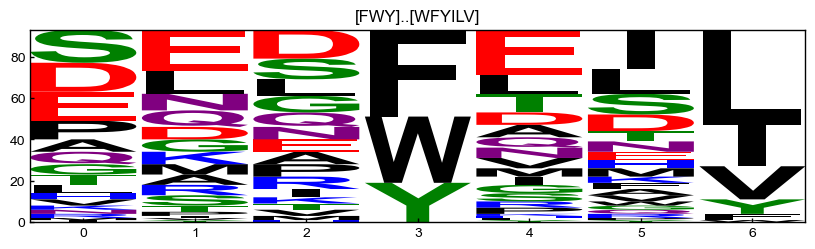

In [80]:
lir_types = temp['lir_type'].unique()
for lir_type in lir_types:
    ax = pssms.plot_logo(pssms.alignment_2_counts(temp[temp['lir_type']==lir_type]['7mer'].tolist()))
    ax.set_title(lir_type)

In [69]:
lir_type

'[FWY]..[WFYILV]'